# 03 -- Datenbankerstellung

Dieses Notebook fuehrt die in Notebook 01 und 02 ausgewaehlten Variablen zu einer einzigen
**Panel-Datenbank** zusammen (Zeile = Land-Jahr). Die anschliessende **Datenbereinigung**
erfolgt separat in Notebook 04.

| Schritt | Beschreibung |
|---------|--------------|
| **1** | Skelett: vollstaendiges Gitter aus 119 Laendern x 16 Jahren (2007-2022) |
| **2** | **DB1** -- Zielvariablen (HDI, Happiness Score) |
| **3** | **DB2** -- alle 37 makrooekonomischen Features |
| **4** | **Finale Roh-DB** -- DB1 + DB2, fehlende Werte als `n/a` |
| **5** | Verifizierung (119 Laender, 37 Features, 2007-2022) |

**Datenquellen:**
- `Created Files for Analysis/config.json` -- Analyserahmen (Laender, Zeitraum, Indikatoren)
- `Created Files for Analysis/wise_data_raw.csv` -- Zielvariablen + 26 WISE-Features (Long-Format)
- `Created Files for Analysis/country_list.xlsx` -- ISO3 -> Laendername
- `Created Files for Analysis/bip_levels_2006_2022.xlsx` -- BIP-Niveau fuer die abgeleitete Wachstumsrate
- `Further Indicator DBs/` -- 10 externe Features (WDI, IMF-GDD, SWIID)

**37 Features = 26 WISE + 10 extern + 1 abgeleitet** (reale BIP-Wachstumsrate `WB-WDI-GDP-ZG`).

**Struktur:** Spalten `ISO3, Country_Name, Year, HDI, Happiness_Score`, danach die 37 Features.
Spaltennamen sind die Codes/Akronyme; ein **Data Dictionary** uebersetzt sie in Klarnamen.


## 0 -- Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import zipfile
import io
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Pfade (relativ zum /code-Verzeichnis)
ANALYSIS_DIR = Path('Created Files for Analysis')
FURTHER_DB   = Path('..') / 'Further Indicator DBs'
OUTPUT_DB    = Path('..') / 'Created DBs' / 'Raw DBs'
OUTPUT_DB.mkdir(parents=True, exist_ok=True)

# Analyserahmen aus config.json (Notebook 01)
with open(ANALYSIS_DIR / 'config.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

INCLUDED_COUNTRIES = sorted(config['included_countries'])  # 119 ISO3
YEAR_START         = config['year_start']                  # 2007
YEAR_END           = config['year_end']                    # 2022
N_YEARS            = config['n_years']                      # 16
N_COUNTRIES        = config['n_countries']                 # 119
TARGET_ACRONYMS    = config['target_acronyms']             # ['UNDP-HDI', 'WHR-LS']
WISE_FEATURES      = config['selected_indicator_acronyms'] # 26 WISE-Akronyme

# ISO3 -> Laendername
country_list = pd.read_excel(ANALYSIS_DIR / 'country_list.xlsx')
ISO3_TO_NAME = dict(zip(country_list['ISO3'], country_list['Country_Name']))

print(f'Studienlaender:   {N_COUNTRIES}')
print(f'Studienzeitraum:  {YEAR_START}-{YEAR_END} ({N_YEARS} Jahre)')
print(f'Zielvariablen:    {TARGET_ACRONYMS}')
print(f'WISE-Features:    {len(WISE_FEATURES)}')
print(f'Ausgabeordner:    {OUTPUT_DB.resolve()}')

Studienlaender:   119
Studienzeitraum:  2007-2022 (16 Jahre)
Zielvariablen:    ['UNDP-HDI', 'WHR-LS']
WISE-Features:    26
Ausgabeordner:    C:\Users\maier\OneDrive\Dokumente\_Studium\Bachelorarbeit\Practical Analysis\Explaining-Well-Being\Created DBs


## 1 -- Skelett: Land x Jahr Gitter

Vollstaendiges Gitter 119 Laender x 16 Jahre = **1904 Zeilen**. Alle Features werden per
Left-Merge angehaengt; fehlende Land-Jahr-Werte werden so automatisch zu `NaN`.

In [2]:
skeleton = (
    pd.MultiIndex
    .from_product([INCLUDED_COUNTRIES, range(YEAR_START, YEAR_END + 1)],
                  names=['ISO3', 'Year'])
    .to_frame(index=False)
)
skeleton.insert(1, 'Country_Name', skeleton['ISO3'].map(ISO3_TO_NAME))

print(f'Skelett: {skeleton.shape[0]} Zeilen '
      f'({skeleton["ISO3"].nunique()} Laender x {skeleton["Year"].nunique()} Jahre)')
assert len(skeleton) == N_COUNTRIES * N_YEARS == 1904
assert skeleton['Country_Name'].notna().all(), 'Fehlende Laendernamen!'
skeleton.head()

Skelett: 1904 Zeilen (119 Laender x 16 Jahre)


,ISO3,Country_Name,Year
0,AFG,Afghanistan,2007
1,AFG,Afghanistan,2008
2,AFG,Afghanistan,2009
3,AFG,Afghanistan,2010
4,AFG,Afghanistan,2011


## 2 -- DB1: Zielvariablen (HDI & Happiness Score)

Aus `wise_data_raw.csv`: Zielvariablen ins Wide-Format pivotieren, umbenennen
(`UNDP-HDI` -> `HDI`, `WHR-LS` -> `Happiness_Score`), auf das Skelett mergen.

In [3]:
wise_raw = pd.read_csv(ANALYSIS_DIR / 'wise_data_raw.csv')
print(f'wise_data_raw.csv: {wise_raw.shape[0]:,} Zeilen, '
      f'{wise_raw["Acronym"].nunique()} Akronyme')

targets_wide = (
    wise_raw[wise_raw['Acronym'].isin(TARGET_ACRONYMS)]
    .pivot_table(index=['ISO3', 'Year'], columns='Acronym', values='Value')
    .reset_index()
    .rename(columns={'UNDP-HDI': 'HDI', 'WHR-LS': 'Happiness_Score'})
)

db1 = skeleton.merge(targets_wide, on=['ISO3', 'Year'], how='left')
db1 = db1[['ISO3', 'Country_Name', 'Year', 'HDI', 'Happiness_Score']]

print(f'DB1: {db1.shape[0]} Zeilen x {db1.shape[1]} Spalten')
print(f'  HDI vorhanden:             {db1["HDI"].notna().sum():4d} / {len(db1)}')
print(f'  Happiness_Score vorhanden: {db1["Happiness_Score"].notna().sum():4d} / {len(db1)}')

db1.to_excel(OUTPUT_DB / 'db1_targets.xlsx', index=False)
db1.to_csv(OUTPUT_DB / 'db1_targets.csv', index=False, na_rep='n/a', encoding='utf-8')
print('Gespeichert: db1_targets.xlsx / .csv')
db1.head()

wise_data_raw.csv: 47,995 Zeilen, 28 Akronyme


DB1: 1904 Zeilen x 5 Spalten
  HDI vorhanden:             1904 / 1904
  Happiness_Score vorhanden: 1781 / 1904


Gespeichert: db1_targets.xlsx / .csv


,ISO3,Country_Name,Year,HDI,Happiness_Score
0,AFG,Afghanistan,2007,0.426,NaN
1,AFG,Afghanistan,2008,0.431,3.723590
2,AFG,Afghanistan,2009,0.441,4.401778
3,AFG,Afghanistan,2010,0.449,4.758381
4,AFG,Afghanistan,2011,0.457,3.831719


## 3 -- DB2: alle 37 makrooekonomischen Features

26 WISE-Features + 10 externe Features + 1 abgeleitetes Feature (reale BIP-Wachstumsrate).

### 3a -- 26 WISE-Features (aus `wise_data_raw.csv`, ohne Zielvariablen)

In [4]:
wise_feat_wide = (
    wise_raw[wise_raw['Acronym'].isin(WISE_FEATURES)]
    .pivot_table(index=['ISO3', 'Year'], columns='Acronym', values='Value')
    .reset_index()
)
wise_feat_wide = wise_feat_wide[['ISO3', 'Year'] + WISE_FEATURES]
print(f'WISE-Features (wide): {wise_feat_wide.shape[1] - 2} Spalten')
assert wise_feat_wide.shape[1] - 2 == 26

WISE-Features (wide): 26 Spalten


### 3b -- 11 externe/abgeleitete Features

Lesefunktionen & Mappings **identisch zu Notebook 02**. Zehn Features stammen aus Dateien
in `Further Indicator DBs`; die **reale BIP-Wachstumsrate** (`WB-WDI-GDP-ZG`) wird aus dem
BIP-Niveau in `bip_levels_2006_2022.xlsx` abgeleitet
($g_x = (BIP_x / BIP_{x-1} - 1)\cdot 100$, Basisjahr 2006).

| Code | Quelle | Datei |
|------|--------|-------|
| FP.CPI.TOTL.ZG | WDI | Inflation.xls |
| NY.GDP.DEFL.KD.ZG | WDI | GPD Deflator.xls |
| FS.AST.PRVT.GD.ZS | WDI | Domestic Credit to Private Sector.xls |
| TT.PRI.MRCH.XD.WD | WDI | Terms of Trade.xls |
| BN.CAB.XOKA.GD.ZS | WDI | Leistungsbilanzsaldo.xls |
| GC.XPN.TOTL.GD.ZS | WDI | Staatsquote.xls |
| FM.LBL.BMNY.GD.ZS | WDI | Broad Money.xls |
| IMF-GDD-CG | IMF Global Debt DB | GlobalDebtDatabase.xlsx |
| SWIID-GINI-DISP | SWIID v9.92 | dataverse_files.zip |
| SWIID-GINI-MKT | SWIID v9.92 | dataverse_files.zip |
| **WB-WDI-GDP-ZG** | **abgeleitet** | **bip_levels_2006_2022.xlsx** |

In [5]:
# ── Lesefunktionen (identisch zu Notebook 02) ──────────────────────────
def read_wdi(filepath):
    """WDI-XLS (Header Zeile 3, Jahre als Spalten) -> Long (ISO3, Year, Value)."""
    df = pd.read_excel(filepath, sheet_name='Data', header=3)
    df = df.rename(columns={'Country Code': 'ISO3'})
    df['ISO3'] = df['ISO3'].astype(str).str.strip()
    year_map = {}
    for col in df.columns:
        try:
            yr = int(float(str(col)))
            if YEAR_START <= yr <= YEAR_END:
                year_map[col] = yr
        except (ValueError, TypeError):
            pass
    if not year_map:
        return pd.DataFrame(columns=['ISO3', 'Year', 'Value'])
    df_long = df[['ISO3'] + list(year_map.keys())].melt(
        id_vars='ISO3', var_name='Year_raw', value_name='Value')
    df_long['Year'] = df_long['Year_raw'].map(year_map).astype(int)
    return df_long[['ISO3', 'Year', 'Value']].dropna(subset=['ISO3'])


def read_global_debt(filepath, gdd_name_to_iso3):
    """IMF Global Debt DB -> Long (ISO3, Year, Value) aus Spalte cg_data."""
    df = pd.read_excel(filepath, sheet_name='rawdata', header=2)
    df['ISO3'] = df['country'].map(gdd_name_to_iso3)
    df = df[df['ISO3'].notna()].copy()
    return df[['ISO3', 'year', 'cg_data']].rename(
        columns={'year': 'Year', 'cg_data': 'Value'})


def read_swiid(filepath, swiid_name_to_iso3):
    """SWIID summary aus verschachteltem ZIP -> voller DataFrame mit ISO3."""
    with zipfile.ZipFile(filepath) as outer:
        with outer.open('swiid9_92.zip') as inner_bytes:
            with zipfile.ZipFile(io.BytesIO(inner_bytes.read())) as inner:
                with inner.open('swiid9_92/swiid9_92_summary.csv') as f:
                    df = pd.read_csv(f)
    df['ISO3'] = df['country'].map(swiid_name_to_iso3)
    return df

In [6]:
# ── Mapping IMF-GDD Laendername -> ISO3 (identisch zu Notebook 02) ──────
GDD_NAME_TO_ISO3 = dict(zip(country_list['Country_Name'], country_list['ISO3']))
GDD_NAME_TO_ISO3.update({
    'U.A.E.':                              'ARE',
    'Bosnia & Herzegovina':                'BIH',
    'China, Mainland':                     'CHN',
    'Congo, Republic of':                  'COG',
    'Czech Republic':                      'CZE',
    'Egypt':                               'EGY',
    'Hong Kong SAR':                       'HKG',
    'Iran, I. Rep. Of':                    'IRN',
    'Korea, Republic of':                  'KOR',
    'Macedonia, FYR':                      'MKD',
    'Venezuela, Republica Bolivariana de': 'VEN',
    'Vietnam':                             'VNM',
    'Yemen':                               'YEM',
})
for _nm in pd.read_excel(FURTHER_DB / 'GlobalDebtDatabase.xlsx',
                         sheet_name='rawdata', header=2)['country'].dropna().unique():
    if 'rkiye' in str(_nm):
        GDD_NAME_TO_ISO3[_nm] = 'TUR'

# ── Mapping SWIID Laendername -> ISO3 (identisch zu Notebook 02) ────────
SWIID_NAME_TO_ISO3 = dict(zip(country_list['Country_Name'], country_list['ISO3']))
SWIID_NAME_TO_ISO3.update({
    'Czech Republic':         'CZE',  'South Korea':              'KOR',
    'Korea':                  'KOR',  'Russia':                   'RUS',
    'Iran':                   'IRN',  'Vietnam':                  'VNM',
    'Yemen':                  'YEM',  'Congo, Republic of the':   'COG',
    'Republic of the Congo':  'COG',  'Congo, Rep.':              'COG',
    'Hong Kong':              'HKG',  'Venezuela':                'VEN',
    'Slovakia':               'SVK',  'North Macedonia':          'MKD',
    'Macedonia':              'MKD',  'Turkey':                   'TUR',
    'Egypt':                  'EGY',  'Bosnia and Herzegovina':   'BIH',
    'Kyrgyzstan':             'KGZ',  'Moldova':                  'MDA',
    'Cambodia':               'KHM',  'UAE':                      'ARE',
    'United Arab Emirates':   'ARE',
})
print('Mappings definiert: GDD + SWIID')

Mappings definiert: GDD + SWIID


In [7]:
# ── Guard: alle benoetigten Quelldateien vorhanden? ────────────────────
WDI_FILES = {
    'FP.CPI.TOTL.ZG':    'Inflation.xls',
    'NY.GDP.DEFL.KD.ZG': 'GPD Deflator.xls',
    'FS.AST.PRVT.GD.ZS': 'Domestic Credit to Private Sector.xls',
    'TT.PRI.MRCH.XD.WD': 'Terms of Trade.xls',
    'BN.CAB.XOKA.GD.ZS': 'Leistungsbilanzsaldo.xls',
    'GC.XPN.TOTL.GD.ZS': 'Staatsquote.xls',
    'FM.LBL.BMNY.GD.ZS': 'Broad Money.xls',
}
required = ([FURTHER_DB / f for f in WDI_FILES.values()] +
            [FURTHER_DB / 'GlobalDebtDatabase.xlsx',
             FURTHER_DB / 'dataverse_files.zip',
             ANALYSIS_DIR / 'bip_levels_2006_2022.xlsx'])
missing = [str(p) for p in required if not p.exists()]
assert not missing, (
    'Fehlende Quelldatei(en): ' + ', '.join(missing) +
    '\nBitte bereitstellen (insb. dataverse_files.zip = SWIID v9.92, Harvard Dataverse), '
    'dann Zelle erneut ausfuehren.'
)
print('Alle Quelldateien vorhanden.')

Alle Quelldateien vorhanden.


In [8]:
# ── Externe Features einlesen -> ein Long-Frame -> Wide ────────────────
ext_long = []

# 7 WDI-Indikatoren
for code_, fname in WDI_FILES.items():
    d = read_wdi(FURTHER_DB / fname)
    d['Acronym'] = code_
    ext_long.append(d[['ISO3', 'Year', 'Acronym', 'Value']])

# IMF Global Debt Database (Central Government Debt, % of GDP)
d = read_global_debt(FURTHER_DB / 'GlobalDebtDatabase.xlsx', GDD_NAME_TO_ISO3)
d['Acronym'] = 'IMF-GDD-CG'
ext_long.append(d[['ISO3', 'Year', 'Acronym', 'Value']])

# SWIID: zwei Gini-Varianten
swiid = read_swiid(FURTHER_DB / 'dataverse_files.zip', SWIID_NAME_TO_ISO3)
for col, code_ in [('gini_disp', 'SWIID-GINI-DISP'), ('gini_mkt', 'SWIID-GINI-MKT')]:
    d = swiid[['ISO3', 'year', col]].rename(columns={'year': 'Year', col: 'Value'})
    d['Acronym'] = code_
    ext_long.append(d[['ISO3', 'Year', 'Acronym', 'Value']])

# ── Abgeleitet: reale BIP-Wachstumsrate aus dem BIP-Niveau ─────────────
# g_x = (BIP_x / BIP_{x-1} - 1) * 100 ; Basisjahr 2006 (in bip_levels enthalten)
gdp_levels = pd.read_excel(ANALYSIS_DIR / 'bip_levels_2006_2022.xlsx')
gdp_wide   = gdp_levels.pivot(index='ISO3', columns='Year', values='GDP')
growth_wide = pd.DataFrame(index=gdp_wide.index)
for yr in range(YEAR_START, YEAR_END + 1):                 # 2007-2022
    if yr in gdp_wide.columns and (yr - 1) in gdp_wide.columns:
        growth_wide[yr] = (gdp_wide[yr] / gdp_wide[yr - 1] - 1) * 100
gdp_growth = (
    growth_wide.reset_index()
    .melt(id_vars='ISO3', var_name='Year', value_name='Value')
    .dropna(subset=['Value'])
)
gdp_growth['Year'] = gdp_growth['Year'].astype(int)
gdp_growth['Acronym'] = 'WB-WDI-GDP-ZG'
ext_long.append(gdp_growth[['ISO3', 'Year', 'Acronym', 'Value']])

# Zusammenfuehren + auf Studienrahmen einschraenken
ext_long = pd.concat(ext_long, ignore_index=True)
ext_long = ext_long[
    ext_long['ISO3'].isin(INCLUDED_COUNTRIES) &
    ext_long['Year'].between(YEAR_START, YEAR_END) &
    ext_long['Value'].notna()
].copy()

EXTERNAL_FEATURES = (list(WDI_FILES.keys()) +
                     ['IMF-GDD-CG', 'SWIID-GINI-DISP', 'SWIID-GINI-MKT', 'WB-WDI-GDP-ZG'])
ext_wide = (
    ext_long.pivot_table(index=['ISO3', 'Year'], columns='Acronym', values='Value')
    .reset_index()
)
ext_wide = ext_wide[['ISO3', 'Year'] + EXTERNAL_FEATURES]
print(f'Externe/abgeleitete Features (wide): {ext_wide.shape[1] - 2} Spalten')
assert ext_wide.shape[1] - 2 == 11, 'Erwartet: 11 externe Features'
for c in EXTERNAL_FEATURES:
    cov = ext_wide.groupby('ISO3')[c].apply(lambda s: s.notna().any()).mean() * 100
    print(f'  {c:22s} Laenderabdeckung: {cov:5.1f}%')

Externe/abgeleitete Features (wide): 11 Spalten
  FP.CPI.TOTL.ZG         Laenderabdeckung: 100.0%
  NY.GDP.DEFL.KD.ZG      Laenderabdeckung: 100.0%
  FS.AST.PRVT.GD.ZS      Laenderabdeckung: 100.0%
  TT.PRI.MRCH.XD.WD      Laenderabdeckung:  99.2%
  BN.CAB.XOKA.GD.ZS      Laenderabdeckung:  97.5%
  GC.XPN.TOTL.GD.ZS      Laenderabdeckung:  88.2%
  FM.LBL.BMNY.GD.ZS      Laenderabdeckung:  83.2%
  IMF-GDD-CG             Laenderabdeckung:  90.8%
  SWIID-GINI-DISP        Laenderabdeckung:  98.3%
  SWIID-GINI-MKT         Laenderabdeckung:  98.3%
  WB-WDI-GDP-ZG          Laenderabdeckung:  99.2%


### 3c -- DB2 zusammensetzen (26 WISE + 11 extern = 37 Features)

In [9]:
ALL_FEATURES = WISE_FEATURES + EXTERNAL_FEATURES   # 26 + 11 = 37

db2 = (
    skeleton
    .merge(wise_feat_wide, on=['ISO3', 'Year'], how='left')
    .merge(ext_wide,       on=['ISO3', 'Year'], how='left')
)
db2 = db2[['ISO3', 'Country_Name', 'Year'] + ALL_FEATURES]

print(f'DB2: {db2.shape[0]} Zeilen x {db2.shape[1]} Spalten '
      f'({len(ALL_FEATURES)} Features)')
assert len(ALL_FEATURES) == 37

db2.to_excel(OUTPUT_DB / 'db2_features.xlsx', index=False)
db2.to_csv(OUTPUT_DB / 'db2_features.csv', index=False, na_rep='n/a', encoding='utf-8')
print('Gespeichert: db2_features.xlsx / .csv')
db2.head()

DB2: 1904 Zeilen x 40 Spalten (37 Features)


Gespeichert: db2_features.xlsx / .csv


,ISO3,Country_Name,Year,UNDP-HDI-GNIPC,WB-WDI-SL-TLF-TOTL-IN,UNDP-HDI-GDI-GNI-PC-F,UNDP-HDI-GDI-GNI-PC-M,UNDP-HDI-GII-LFPR-F,UNDP-HDI-GII-LFPR-M,WB-WDI-FM-AST-NFRG-CN,...,NY.GDP.DEFL.KD.ZG,FS.AST.PRVT.GD.ZS,TT.PRI.MRCH.XD.WD,BN.CAB.XOKA.GD.ZS,GC.XPN.TOTL.GD.ZS,FM.LBL.BMNY.GD.ZS,IMF-GDD-CG,SWIID-GINI-DISP,SWIID-GINI-MKT,WB-WDI-GDP-ZG
0,AFG,Afghanistan,2007,1894.877589,6115891.0,NaN,NaN,NaN,NaN,1.470796e+11,...,22.527756,6.839982,110.8,NaN,24.243259,23.833664,20.136631,31.4,32.7,13.826320
1,AFG,Afghanistan,2008,1838.976743,6210225.0,1033.807013,2629.006826,43.79,82.04,1.727839e+11,...,2.096289,9.388328,106.7,-2.357990,50.719298,29.512281,19.057076,31.4,32.8,3.924984
2,AFG,Afghanistan,2009,1953.658150,6504675.0,1014.018123,2874.907179,36.85,80.79,2.148289e+11,...,-2.163404,10.584131,108.0,2.236019,44.317839,33.060957,16.247261,31.5,32.9,21.390528
3,AFG,Afghanistan,2010,2006.788911,6738587.0,944.204099,3047.653841,29.90,79.55,2.480988e+11,...,3.814630,11.575044,115.7,-3.643314,50.863005,35.350562,7.696949,31.6,33.0,14.362441
4,AFG,Afghanistan,2011,2059.012272,7095658.0,795.393800,3296.007461,22.96,78.30,3.381263e+11,...,16.593347,4.959180,116.7,-12.619538,59.484776,36.624228,7.501084,31.7,33.1,0.426355


## 4 -- Finale Roh-Datenbank

DB1 (Zielvariablen) + DB2 (37 Features). Spaltenreihenfolge: `ISO3, Country_Name, Year,
HDI, Happiness_Score`, danach die 37 Features. Fehlende Werte werden beim Export als `n/a`
geschrieben. Ein **Data Dictionary** uebersetzt jeden Code in Klarname, Einheit, Quelle, Kategorie.

In [10]:
database_raw = db1.merge(db2, on=['ISO3', 'Country_Name', 'Year'], how='left')

COL_ORDER = ['ISO3', 'Country_Name', 'Year', 'HDI', 'Happiness_Score'] + ALL_FEATURES
database_raw = database_raw[COL_ORDER]

print(f'Finale Roh-DB: {database_raw.shape[0]} Zeilen x {database_raw.shape[1]} Spalten')
print(f'  = 3 ID + 2 Zielvariablen + {len(ALL_FEATURES)} Features')
database_raw.head()

Finale Roh-DB: 1904 Zeilen x 42 Spalten
  = 3 ID + 2 Zielvariablen + 37 Features


,ISO3,Country_Name,Year,HDI,Happiness_Score,UNDP-HDI-GNIPC,WB-WDI-SL-TLF-TOTL-IN,UNDP-HDI-GDI-GNI-PC-F,UNDP-HDI-GDI-GNI-PC-M,UNDP-HDI-GII-LFPR-F,...,NY.GDP.DEFL.KD.ZG,FS.AST.PRVT.GD.ZS,TT.PRI.MRCH.XD.WD,BN.CAB.XOKA.GD.ZS,GC.XPN.TOTL.GD.ZS,FM.LBL.BMNY.GD.ZS,IMF-GDD-CG,SWIID-GINI-DISP,SWIID-GINI-MKT,WB-WDI-GDP-ZG
0,AFG,Afghanistan,2007,0.426,NaN,1894.877589,6115891.0,NaN,NaN,NaN,...,22.527756,6.839982,110.8,NaN,24.243259,23.833664,20.136631,31.4,32.7,13.826320
1,AFG,Afghanistan,2008,0.431,3.723590,1838.976743,6210225.0,1033.807013,2629.006826,43.79,...,2.096289,9.388328,106.7,-2.357990,50.719298,29.512281,19.057076,31.4,32.8,3.924984
2,AFG,Afghanistan,2009,0.441,4.401778,1953.658150,6504675.0,1014.018123,2874.907179,36.85,...,-2.163404,10.584131,108.0,2.236019,44.317839,33.060957,16.247261,31.5,32.9,21.390528
3,AFG,Afghanistan,2010,0.449,4.758381,2006.788911,6738587.0,944.204099,3047.653841,29.90,...,3.814630,11.575044,115.7,-3.643314,50.863005,35.350562,7.696949,31.6,33.0,14.362441
4,AFG,Afghanistan,2011,0.457,3.831719,2059.012272,7095658.0,795.393800,3296.007461,22.96,...,16.593347,4.959180,116.7,-12.619538,59.484776,36.624228,7.501084,31.7,33.1,0.426355


In [11]:
# ── Data Dictionary aufbauen ───────────────────────────────────────────
def source_from_acronym(acr):
    if acr.startswith('UNDP-HDI'): return 'UNDP Human Development Report'
    if acr.startswith('WHR-LS'):   return 'World Happiness Report / Gallup'
    if acr.startswith('WB-WDI'):   return 'World Bank -- World Development Indicators'
    if acr.startswith('WB-CWON'):  return 'World Bank -- Changing Wealth of Nations'
    return ''

wise_meta = (wise_raw.drop_duplicates('Acronym')
             .set_index('Acronym')[['Metric_Name', 'Unit']])

# Manuelle Eintraege: Zielvariablen + 10 externe + 1 abgeleitetes Feature
MANUAL_DICT = {
    'HDI':             ('Human Development Index', 'Human Development Index (Zielvariable, objektiv)',
                        'Index 0-1', 'UNDP Human Development Report', 'Zielvariable'),
    'Happiness_Score': ('Life Satisfaction (Cantril Ladder)', 'Happiness Score (Zielvariable, subjektiv)',
                        'Skala 0-10', 'World Happiness Report / Gallup', 'Zielvariable'),
    'FP.CPI.TOTL.ZG':  ('Inflation, consumer prices (annual %)', 'Inflation (Verbraucherpreise)',
                        '% p.a.', 'World Bank -- World Development Indicators', 'Preise / Inflation'),
    'NY.GDP.DEFL.KD.ZG':('Inflation, GDP deflator (annual %)', 'BIP-Deflator',
                        '% p.a.', 'World Bank -- World Development Indicators', 'Preise / Inflation'),
    'FS.AST.PRVT.GD.ZS':('Domestic credit to private sector (% of GDP)', 'Kreditvergabe an den Privatsektor',
                        '% des BIP', 'World Bank -- World Development Indicators', 'Finanzsektor'),
    'TT.PRI.MRCH.XD.WD':('Net barter terms of trade index', 'Terms of Trade',
                        'Index (2015=100)', 'World Bank -- World Development Indicators', 'Aussenhandel'),
    'BN.CAB.XOKA.GD.ZS':('Current account balance (% of GDP)', 'Leistungsbilanzsaldo',
                        '% des BIP', 'World Bank -- World Development Indicators', 'Aussenwirtschaft'),
    'GC.XPN.TOTL.GD.ZS':('Expense (% of GDP)', 'Staatsquote (Staatsausgaben)',
                        '% des BIP', 'World Bank -- World Development Indicators', 'Staat / Fiskal'),
    'FM.LBL.BMNY.GD.ZS':('Broad money (% of GDP)', 'Breite Geldmenge (M2)',
                        '% des BIP', 'World Bank -- World Development Indicators', 'Geldmenge'),
    'IMF-GDD-CG':      ('Central government debt (% of GDP)', 'Zentralstaatsverschuldung',
                        '% des BIP', 'IMF Global Debt Database (Mbaye et al. 2018)', 'Staat / Fiskal'),
    'SWIID-GINI-DISP': ('Gini, disposable income (post-tax/transfer)', 'Gini verfuegbares Einkommen',
                        'Gini-Punkte 0-100', 'SWIID v9.92 (Solt 2019)', 'Ungleichheit'),
    'SWIID-GINI-MKT':  ('Gini, market income (pre-tax/transfer)', 'Gini Markteinkommen',
                        'Gini-Punkte 0-100', 'SWIID v9.92 (Solt 2019)', 'Ungleichheit'),
    'WB-WDI-GDP-ZG':   ('Real GDP growth (annual %)', 'BIP-Wachstumsrate (real)',
                        '% p.a.', 'Abgeleitet aus WISE-BIP-Niveau WB-WDI-NY-GDP-MKTP-KD (World Bank WDI)',
                        'Konjunktur'),
}

dict_rows = []
for col in COL_ORDER:
    if col in ('ISO3', 'Country_Name', 'Year'):
        continue
    if col in MANUAL_DICT:
        name_en, name_de, unit, src, cat = MANUAL_DICT[col]
    else:  # WISE-Feature
        name_en = wise_meta.loc[col, 'Metric_Name'] if col in wise_meta.index else col
        unit    = wise_meta.loc[col, 'Unit']        if col in wise_meta.index else ''
        name_de = ''
        src     = source_from_acronym(col)
        cat     = 'WISE-Feature'
    rolle = ('Zielvariable' if col in ('HDI', 'Happiness_Score')
             else 'Feature (WISE)' if col in WISE_FEATURES
             else 'Feature (extern/abgeleitet)')
    dict_rows.append({'Code': col, 'Name_EN': name_en, 'Name_DE': name_de,
                      'Einheit': unit, 'Quelle': src, 'Kategorie': cat, 'Rolle': rolle})

data_dictionary = pd.DataFrame(dict_rows)
print(f'Data Dictionary: {len(data_dictionary)} Eintraege (2 Zielvariablen + 37 Features)')
data_dictionary

Data Dictionary: 39 Eintraege (2 Zielvariablen + 37 Features)


,Code,Name_EN,Name_DE,Einheit,Quelle,Kategorie,Rolle
0,HDI,Human Development Index,"Human Development Index (Zielvariable, objektiv)",Index 0-1,UNDP Human Development Report,Zielvariable,Zielvariable
1,Happiness_Score,Life Satisfaction (Cantril Ladder),"Happiness Score (Zielvariable, subjektiv)",Skala 0-10,World Happiness Report / Gallup,Zielvariable,Zielvariable
2,UNDP-HDI-GNIPC,Gross national income (GNI) per capita,,2017 PPP $,UNDP Human Development Report,WISE-Feature,Feature (WISE)
3,WB-WDI-SL-TLF-TOTL-IN,"Labor force, total",,People,World Bank -- World Development Indicators,WISE-Feature,Feature (WISE)
4,UNDP-HDI-GDI-GNI-PC-F,Estimated gross national income per capita (Fe...,,2017 PPP $,UNDP Human Development Report,WISE-Feature,Feature (WISE)
5,UNDP-HDI-GDI-GNI-PC-M,Estimated gross national income per capita (Male),,2017 PPP $,UNDP Human Development Report,WISE-Feature,Feature (WISE)
6,UNDP-HDI-GII-LFPR-F,Labour force participation rate (Female),,% Ages 15 And Older,UNDP Human Development Report,WISE-Feature,Feature (WISE)
7,UNDP-HDI-GII-LFPR-M,Labour force participation rate (Male),,% Ages 15 And Older,UNDP Human Development Report,WISE-Feature,Feature (WISE)
8,WB-WDI-FM-AST-NFRG-CN,Net foreign assets,,current LCU,World Bank -- World Development Indicators,WISE-Feature,Feature (WISE)
9,WB-WDI-EG-EGY-PRIM-PP-KD,Energy intensity level of primary energy,,MJ/$2017 PPP GDP,World Bank -- World Development Indicators,WISE-Feature,Feature (WISE)


In [12]:
# ── Export finale Roh-DB (fehlende Werte als n/a) ──────────────────────
with pd.ExcelWriter(OUTPUT_DB / 'final_database_raw.xlsx', engine='openpyxl') as writer:
    database_raw.to_excel(writer, sheet_name='Data', index=False, na_rep='n/a')
    data_dictionary.to_excel(writer, sheet_name='Data Dictionary', index=False)

database_raw.to_csv(OUTPUT_DB / 'final_database_raw.csv',
                    index=False, na_rep='n/a', encoding='utf-8')
print('Gespeichert: final_database_raw.xlsx (Data + Data Dictionary) / final_database_raw.csv')

Gespeichert: final_database_raw.xlsx (Data + Data Dictionary) / final_database_raw.csv


## 5 -- Verifizierung

Pruefung der geforderten Struktur: **119 Laender x 16 Jahre (2007-2022) = 1904 Zeilen**,
**37 Features + 2 Zielvariablen**, keine Duplikate.

In [13]:
feature_cols = [c for c in database_raw.columns
                if c not in ('ISO3', 'Country_Name', 'Year', 'HDI', 'Happiness_Score')]

assert database_raw['ISO3'].nunique() == 119, 'Erwartet 119 Laender'
assert sorted(database_raw['Year'].unique()) == list(range(2007, 2023)), 'Erwartet 2007-2022'
assert len(database_raw) == 1904, 'Erwartet 1904 Zeilen'
assert len(feature_cols) == 37, 'Erwartet 37 Features'
assert {'HDI', 'Happiness_Score'}.issubset(database_raw.columns), 'Zielvariablen fehlen'
assert database_raw.duplicated(['ISO3', 'Year']).sum() == 0, 'Doppelte (ISO3, Year)'

print('=== VERIFIZIERUNG BESTANDEN ===')
print(f'  Laender:        {database_raw["ISO3"].nunique()}  (erwartet 119)')
print(f'  Jahre:          {database_raw["Year"].min()}-{database_raw["Year"].max()}  '
      f'({database_raw["Year"].nunique()} Jahre, erwartet 16)')
print(f'  Zeilen:         {len(database_raw)}  (erwartet 1904)')
print(f'  Zielvariablen:  2  (HDI, Happiness_Score)')
print(f'  Features:       {len(feature_cols)}  (erwartet 37)')
print(f'  Duplikate:      {database_raw.duplicated(["ISO3", "Year"]).sum()}')

=== VERIFIZIERUNG BESTANDEN ===
  Laender:        119  (erwartet 119)
  Jahre:          2007-2022  (16 Jahre, erwartet 16)
  Zeilen:         1904  (erwartet 1904)
  Zielvariablen:  2  (HDI, Happiness_Score)
  Features:       37  (erwartet 37)
  Duplikate:      0


In [14]:
# ── Coverage je Spalte (Plausibilitaetsabgleich mit NB 01/02) ──────────
value_cols = ['HDI', 'Happiness_Score'] + feature_cols
cov_rows = []
for c in value_cols:
    n_obs   = database_raw[c].notna().sum()
    pct_obs = n_obs / len(database_raw) * 100
    country_pct = database_raw.groupby('ISO3')[c].apply(lambda s: s.notna().any()).mean() * 100
    cov_rows.append({'Spalte': c, 'n_Werte': n_obs,
                     'Zellenabdeckung_%': round(pct_obs, 1),
                     'Laenderabdeckung_%': round(country_pct, 1)})
coverage_overview = pd.DataFrame(cov_rows).sort_values('Zellenabdeckung_%', ascending=False)
print('Coverage-Uebersicht (alle Spalten):')
coverage_overview.reset_index(drop=True)

Coverage-Uebersicht (alle Spalten):


,Spalte,n_Werte,Zellenabdeckung_%,Laenderabdeckung_%
0,HDI,1904,100.0,100.0
1,UNDP-HDI-GNIPC,1904,100.0,100.0
2,WB-WDI-SL-TLF-TOTL-IN,1903,99.9,100.0
3,NY.GDP.DEFL.KD.ZG,1900,99.8,100.0
4,WB-WDI-NY-GDP-PCAP-KD,1886,99.1,99.2
5,TT.PRI.MRCH.XD.WD,1883,98.9,99.2
6,WB-WDI-NY-GDP-MKTP-KD,1882,98.8,99.2
7,WB-WDI-GDP-ZG,1882,98.8,99.2
8,UNDP-HDI-GII-LFPR-F,1880,98.7,100.0
9,UNDP-HDI-GDI-GNI-PC-F,1880,98.7,100.0


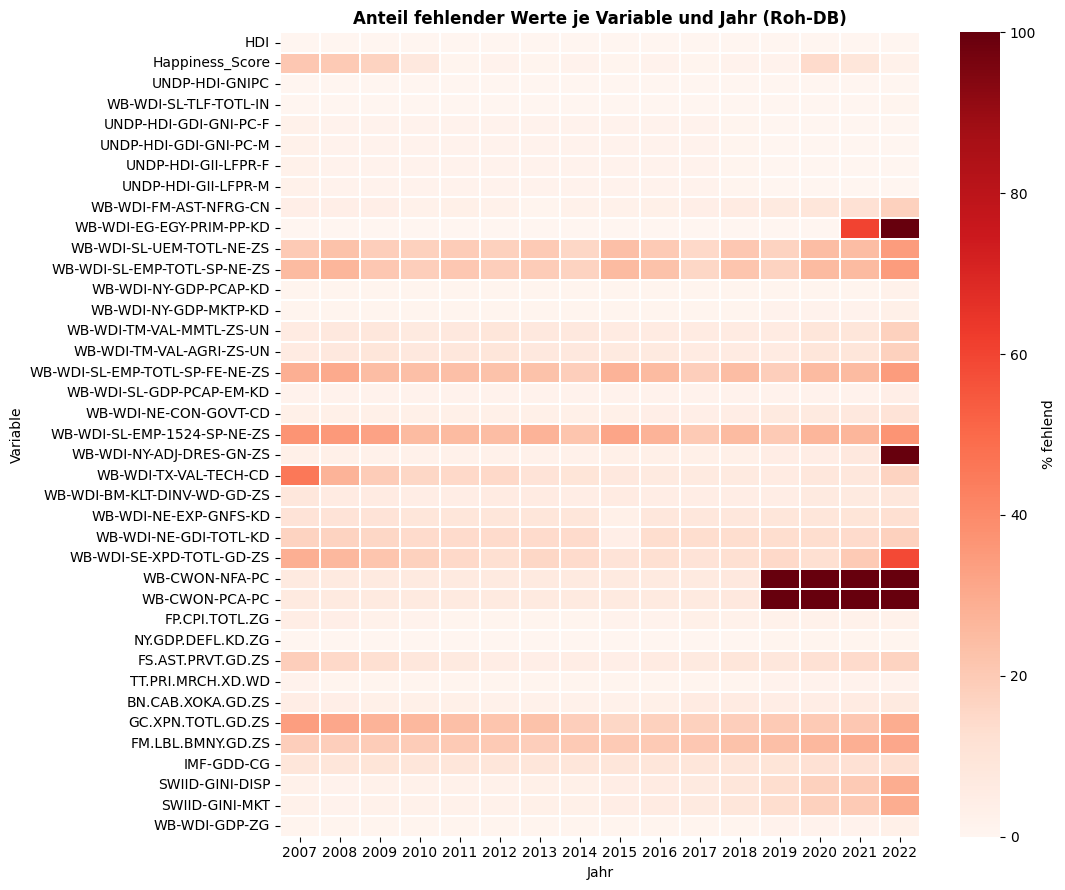

In [15]:
# ── Missing-Heatmap (Spalten x Jahr, % fehlend) ────────────────────────
miss_by_year = (
    database_raw.groupby('Year')[value_cols]
    .apply(lambda g: g.isna().mean() * 100)
)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(miss_by_year.T, cmap='Reds', vmin=0, vmax=100,
            cbar_kws={'label': '% fehlend'}, linewidths=0.3, linecolor='white', ax=ax)
ax.set_title('Anteil fehlender Werte je Variable und Jahr (Roh-DB)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Jahr'); ax.set_ylabel('Variable')
plt.tight_layout()
plt.show()

## Zusammenfassung

| Datei (in `Created DBs/`) | Inhalt |
|---------------------------|--------|
| `db1_targets.xlsx/.csv` | ISO3, Land, Jahr + Zielvariablen (HDI, Happiness_Score) |
| `db2_features.xlsx/.csv` | ISO3, Land, Jahr + 37 Features |
| `final_database_raw.xlsx/.csv` | Zielvariablen + 37 Features, fehlende Werte = `n/a` (+ Data Dictionary) |

**Struktur:** 1904 Zeilen (119 Laender x 16 Jahre 2007-2022), 2 Zielvariablen + 37 Features.
Die **Datenbereinigung inkl. Imputation** erfolgt in **Notebook 04** auf Basis von
`final_database_raw`.
